
# Analisis dan Filtering Domain Frekuensi dengan FFT dan Wavelet

## Output yang dihasilkan:
- Visualisasi spektrum (magnitudo & fase) dan koefisien wavelet
- Perbandingan metrik (PSNR, waktu komputasi) untuk berbagai metode filtering/denoising
- Analisis interpretasi frekuensi (penjelasan di setiap langkah)

**Struktur program:**  
Langkah 1 – Penyiapan citra  
Langkah 2 – Transformasi Fourier dan spektrum  
Langkah 3 – Filtering domain frekuensi (ideal, Gaussian, notch)  
Langkah 4 – Transformasi Wavelet 2D  
Langkah 5 – Evaluasi: perbandingan spasial vs frekuensi, efek cutoff, wavelet denoising + metrik (PSNR, waktu)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import fftpack, ndimage
from skimage import data, img_as_float
import pywt
import time

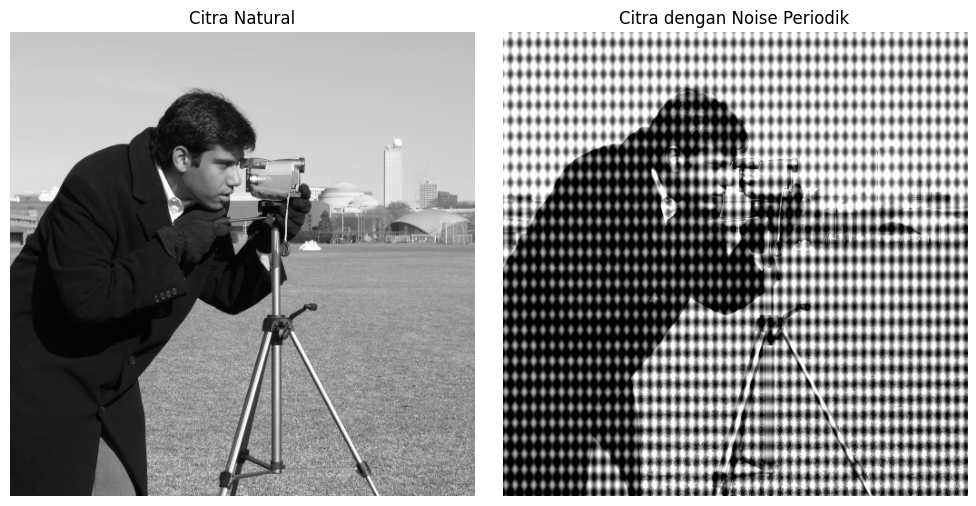

In [2]:
# Langkah 1: Menyiapkan Citra Natural dan Citra dengan Noise Periodik
# Muat citra natural grayscale
image_natural = img_as_float(data.camera())   # 512x512

# Tambahkan noise periodik
M, N = image_natural.shape
x = np.arange(N)
y = np.arange(M)
X, Y = np.meshgrid(x, y)

freq_x, freq_y = 50, 30
noise_periodic = 0.3 * (np.sin(2*np.pi*freq_x*X/N) + np.sin(2*np.pi*freq_y*Y/M))
image_noisy_periodic = np.clip(image_natural + noise_periodic, 0, 1)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))
ax1.imshow(image_natural, cmap='gray')
ax1.set_title("Citra Natural")
ax1.axis('off')
ax2.imshow(image_noisy_periodic, cmap='gray')
ax2.set_title("Citra dengan Noise Periodik")
ax2.axis('off')
plt.tight_layout()
plt.show()

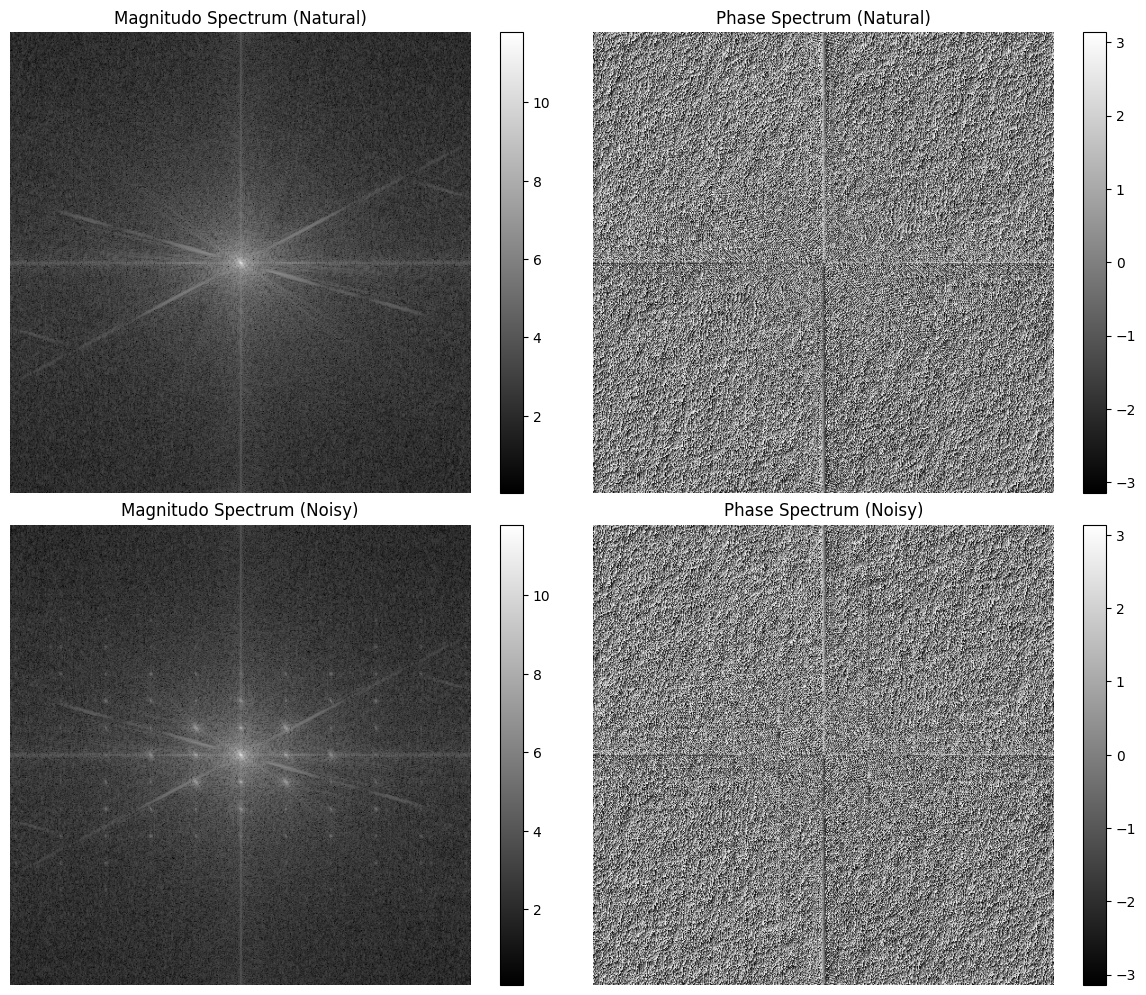

In [3]:
# Langkah 2: Transformasi Fourier – Spektrum Magnitudo & Fase
# FFT citra natural dan noisy
F_nat = fftpack.fft2(image_natural)
F_nat_shift = fftpack.fftshift(F_nat)
mag_nat = np.log(np.abs(F_nat_shift) + 1)
phase_nat = np.angle(F_nat_shift)

F_noisy = fftpack.fft2(image_noisy_periodic)
F_noisy_shift = fftpack.fftshift(F_noisy)
mag_noisy = np.log(np.abs(F_noisy_shift) + 1)
phase_noisy = np.angle(F_noisy_shift)

fig, axes = plt.subplots(2,2, figsize=(12,10))
im0 = axes[0,0].imshow(mag_nat, cmap='gray')
axes[0,0].set_title('Magnitudo Spectrum (Natural)')
plt.colorbar(im0, ax=axes[0,0])
axes[0,0].axis('off')

im1 = axes[0,1].imshow(phase_nat, cmap='gray')
axes[0,1].set_title('Phase Spectrum (Natural)')
plt.colorbar(im1, ax=axes[0,1])
axes[0,1].axis('off')

im2 = axes[1,0].imshow(mag_noisy, cmap='gray')
axes[1,0].set_title('Magnitudo Spectrum (Noisy)')
plt.colorbar(im2, ax=axes[1,0])
axes[1,0].axis('off')

im3 = axes[1,1].imshow(phase_noisy, cmap='gray')
axes[1,1].set_title('Phase Spectrum (Noisy)')
plt.colorbar(im3, ax=axes[1,1])
axes[1,1].axis('off')

plt.tight_layout()
plt.show()

**Interpretasi frekuensi:**  
- Pada spektrum magnitudo natural, energi terpusat di pusat (frekuensi rendah).  
- Pada spektrum magnitudo noisy, muncul **spike (titik terang) simetris** di sekitar pusat akibat noise periodik.  
  Spike di frekuensi (±50,0) dan (0,±30) bersesuaian dengan gelombang sinus horizontal 50 siklus/gambar dan vertikal 30 siklus/gambar.  
- Spektrum fase noisy tampak lebih acak, terutama pada area spike.


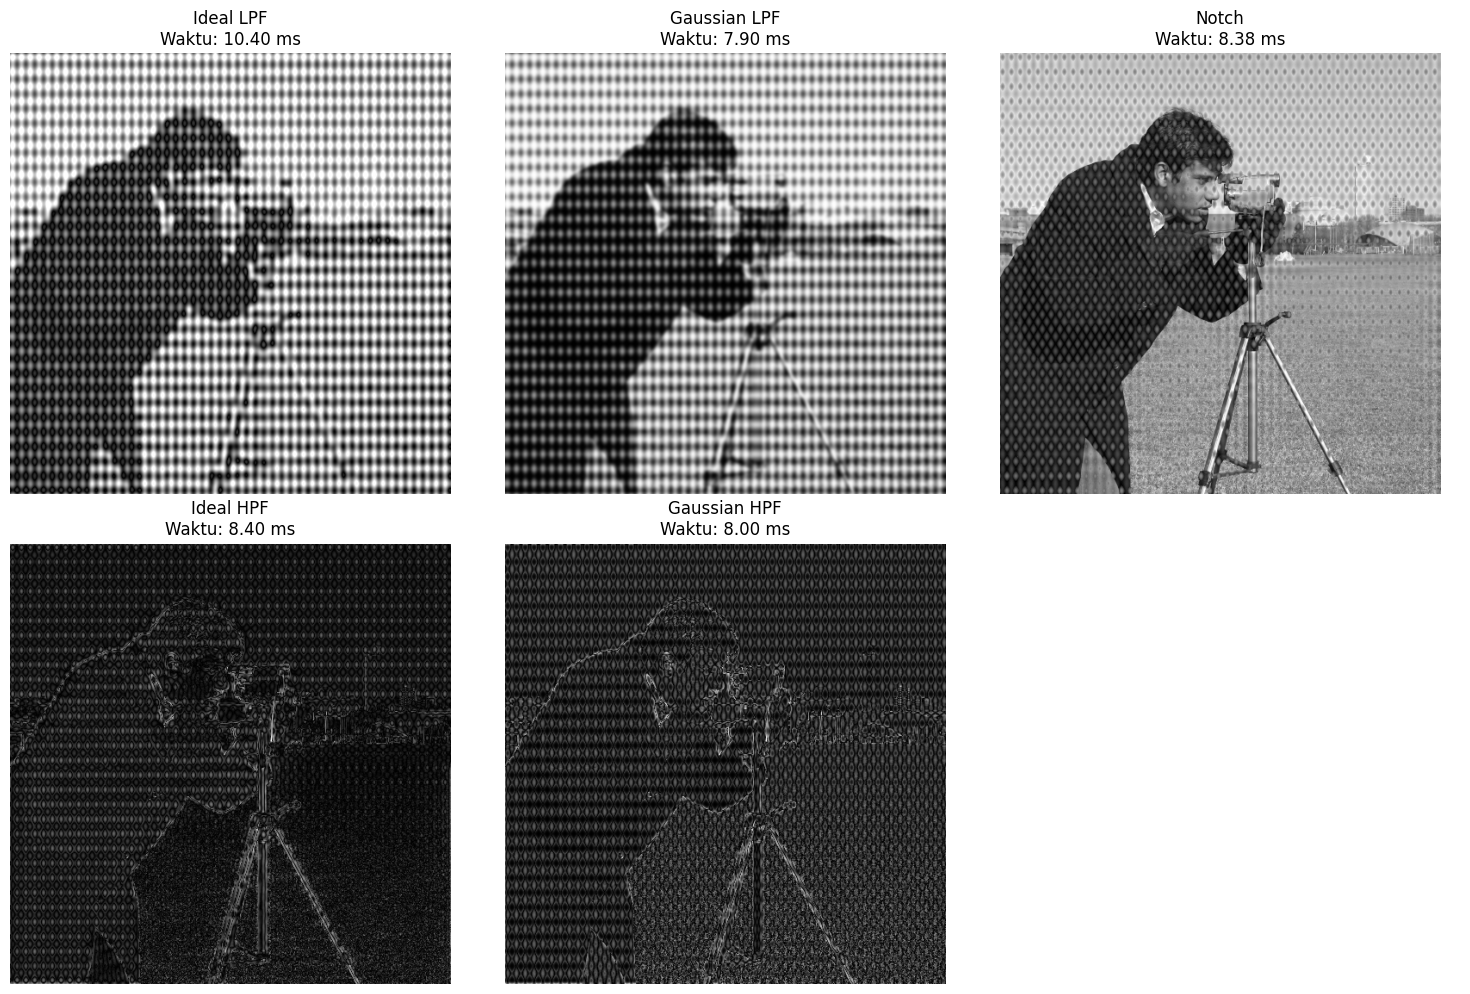

In [4]:
# Langkah 3: Filtering Domain Frekuensi
# Definisikan fungsi filter
def dist_grid(shape):
    M,N = shape
    u = np.arange(N) - N//2
    v = np.arange(M) - M//2
    U,V = np.meshgrid(u, v)
    return np.sqrt(U**2 + V**2)

def ideal_lp(shape, D0):
    D = dist_grid(shape)
    return (D <= D0).astype(np.float64)

def gaussian_lp(shape, D0):
    D = dist_grid(shape)
    return np.exp(-(D**2)/(2*(D0**2)))

# Notch filter untuk noise periodik yang spesifik
crow, ccol = M//2, N//2
notch_centers = [(crow, ccol+freq_x), (crow, ccol-freq_x),
                 (crow+freq_y, ccol), (crow-freq_y, ccol)]
notch_mask = np.ones((M,N), np.float64)
r = 5
Ygrid, Xgrid = np.ogrid[:M, :N]
for (rv, cv) in notch_centers:
    dist = np.sqrt((Xgrid - cv)**2 + (Ygrid - rv)**2)
    notch_mask[dist <= r] = 0

# Pilih cutoff untuk perbandingan
D0 = 50
ilpf = ideal_lp((M,N), D0)
glpf = gaussian_lp((M,N), D0)

# Filtering dan hitung waktu
methods = {
    'Ideal LPF': ilpf,
    'Gaussian LPF': glpf,
    'Notch': notch_mask,
    'Ideal HPF': 1 - ilpf,
    'Gaussian HPF': 1 - glpf
}

results_freq = {}
times_freq = {}
for name, mask in methods.items():
    start = time.time()
    F_filt = F_noisy_shift * mask
    img = np.abs(fftpack.ifft2(fftpack.ifftshift(F_filt)))
    img = np.clip(img, 0, 1)
    elapsed = time.time() - start
    results_freq[name] = img
    times_freq[name] = elapsed

# Tampilkan hasil filtering
fig, axes = plt.subplots(2, 3, figsize=(15,10))
axes = axes.ravel()
for ax, (name, img) in zip(axes, results_freq.items()):
    ax.imshow(img, cmap='gray')
    ax.set_title(f"{name}\nWaktu: {times_freq[name]*1000:.2f} ms")
    ax.axis('off')
# Hapus axes kosong jika ganjil
if len(results_freq) < len(axes):
    for ax in axes[len(results_freq):]:
        ax.axis('off')
plt.tight_layout()
plt.show()

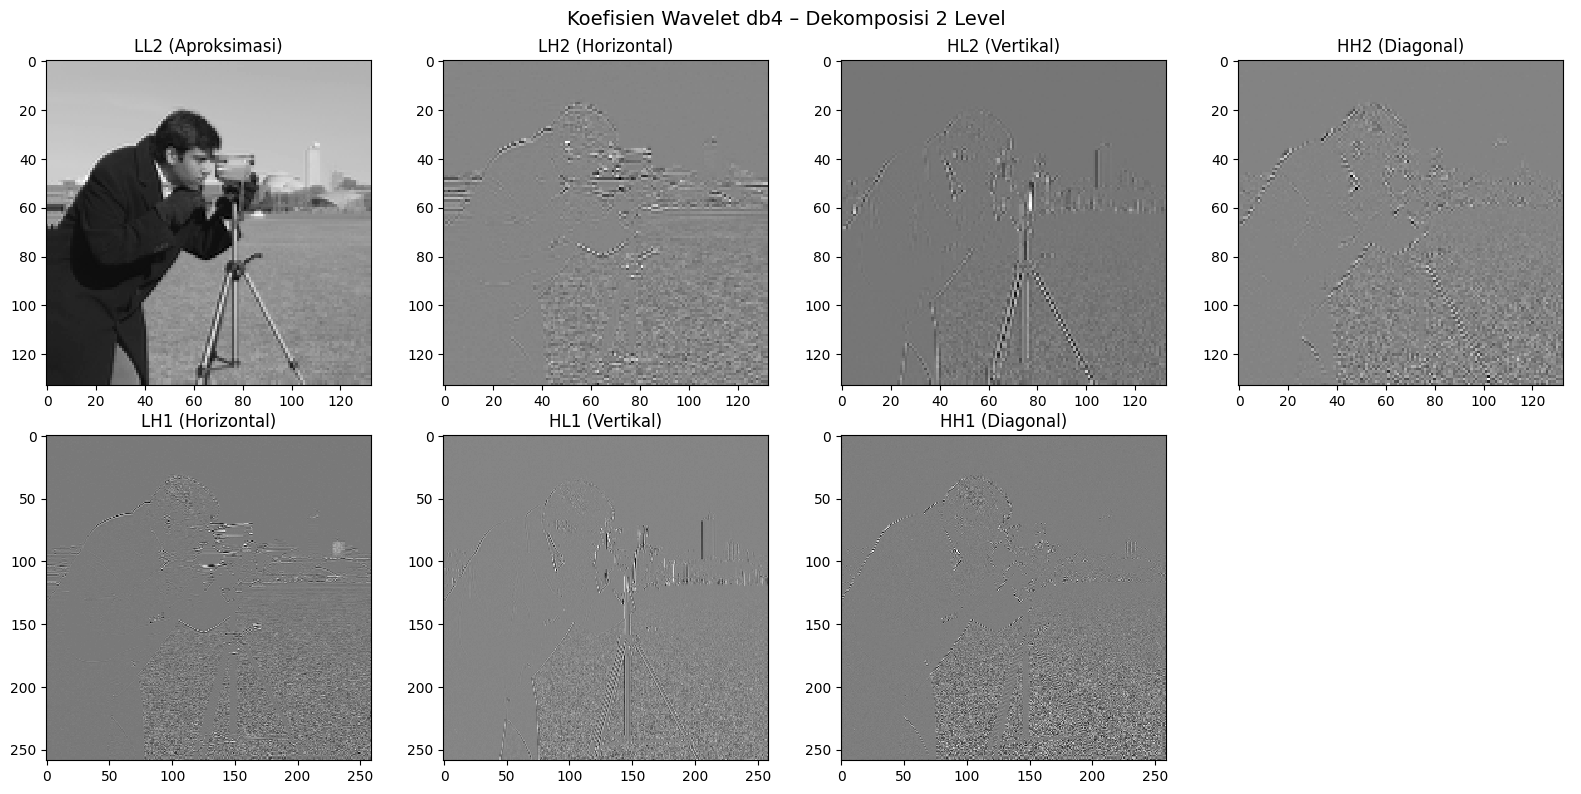

In [5]:
# Langkah 4: Transformasi Wavelet 2D – Visualisasi Koefisien
# Dekomposisi 2 level dengan db4
wavelet = 'db4'
level = 2
coeffs_db4 = pywt.wavedec2(image_natural, wavelet, level=level)
cA2, (cH2, cV2, cD2), (cH1, cV1, cD1) = coeffs_db4

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
# Level 2 koefisien
axes[0,0].imshow(cA2, cmap='gray', interpolation='nearest')
axes[0,0].set_title('LL2 (Aproksimasi)')
axes[0,1].imshow(cH2, cmap='gray', interpolation='nearest')
axes[0,1].set_title('LH2 (Horizontal)')
axes[0,2].imshow(cV2, cmap='gray', interpolation='nearest')
axes[0,2].set_title('HL2 (Vertikal)')
axes[0,3].imshow(cD2, cmap='gray', interpolation='nearest')
axes[0,3].set_title('HH2 (Diagonal)')
# Level 1 koefisien detail
axes[1,0].imshow(cH1, cmap='gray', interpolation='nearest')
axes[1,0].set_title('LH1 (Horizontal)')
axes[1,1].imshow(cV1, cmap='gray', interpolation='nearest')
axes[1,1].set_title('HL1 (Vertikal)')
axes[1,2].imshow(cD1, cmap='gray', interpolation='nearest')
axes[1,2].set_title('HH1 (Diagonal)')
axes[1,3].axis('off')
plt.suptitle('Koefisien Wavelet db4 – Dekomposisi 2 Level', fontsize=14)
plt.tight_layout()
plt.show()

**Interpretasi koefisien wavelet:**  
- LL2 adalah versi low‑pass dari citra (skala kecil).  
- LH mendeteksi tepi horizontal, HL mendeteksi tepi vertikal, HH mendeteksi diagonal/tekstur.  
- Level 1 memiliki detail lebih halus, level 2 lebih kasar. Ini adalah representasi multi‑skala yang efisien.

===== PSNR untuk Noise Periodik (ideal clean = image_natural) =====
Noisy input                          : 11.96 dB
Ideal LPF            : 12.52 dB  (waktu 10.40 ms)
Gaussian LPF         : 14.36 dB  (waktu 7.90 ms)
Notch                : 21.24 dB  (waktu 8.38 ms)
Ideal HPF            : 5.45 dB  (waktu 8.40 ms)
Gaussian HPF         : 5.69 dB  (waktu 8.00 ms)

===== Denoising Gaussian Noise (σ=0.05) =====
Noisy input                          : 26.19 dB
Wavelet denoising    : 26.20 dB  (waktu 16.13 ms)
Gaussian LPF (D0=50) : 26.38 dB  (waktu 20.87 ms)


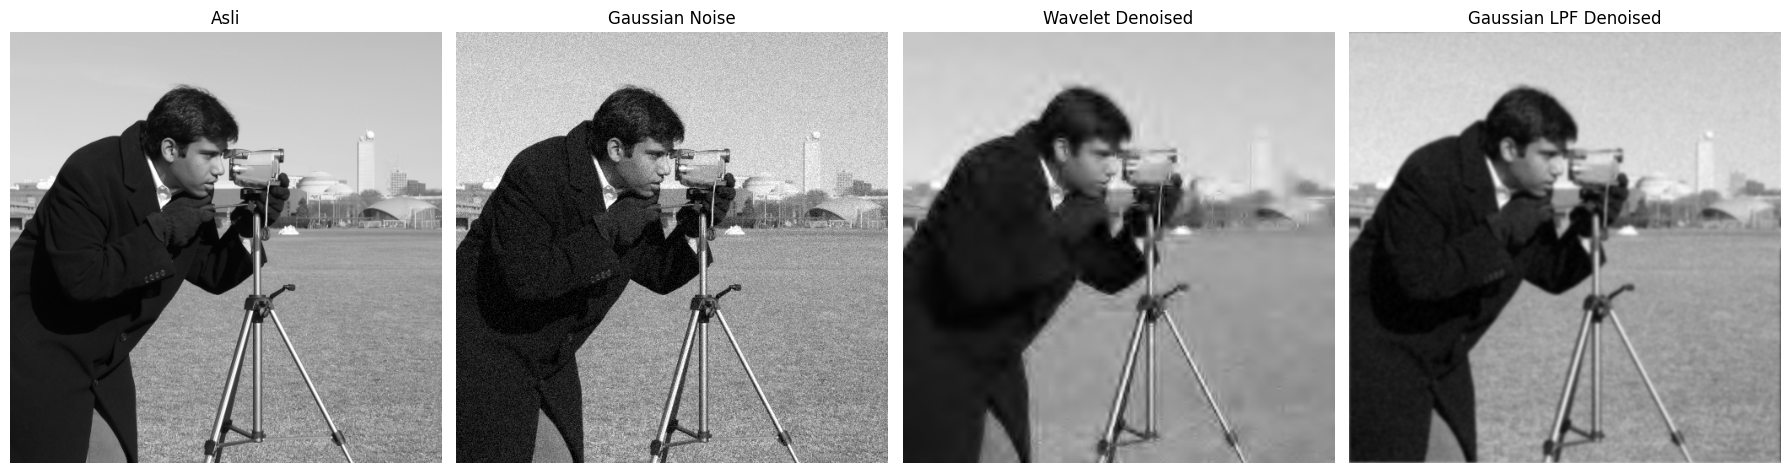


===== Efek Cutoff Ideal LPF (PSNR & Waktu) =====
D0=10 : PSNR=4.70 dB, waktu=12.99 ms
D0=30 : PSNR=4.71 dB, waktu=13.09 ms
D0=70 : PSNR=4.73 dB, waktu=18.71 ms


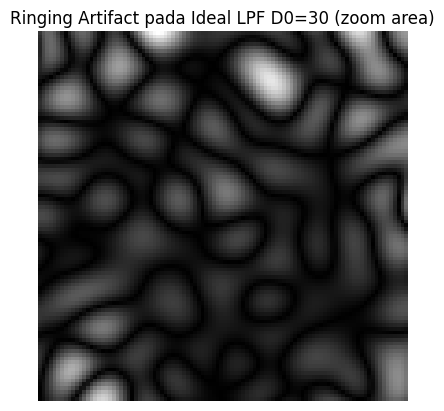

In [6]:
# Langkah 5: Evaluasi – PSNR, Waktu Komputasi, Analisis
# Fungsi PSNR
def psnr(clean, noisy):
    mse = np.mean((clean - noisy)**2)
    if mse == 0:
        return float('inf')
    max_pixel = 1.0
    return 20 * np.log10(max_pixel / np.sqrt(mse))

# ----- 5.1 Perbandingan PSNR dan waktu filtering frekuensi (noise periodik) -----
print("===== PSNR untuk Noise Periodik (ideal clean = image_natural) =====")
print(f"Noisy input                          : {psnr(image_natural, image_noisy_periodic):.2f} dB")
for name, img in results_freq.items():
    print(f"{name:20s} : {psnr(image_natural, img):.2f} dB  (waktu {times_freq[name]*1000:.2f} ms)")

# ----- 5.2 Denoising Gaussian noise dengan wavelet dan GLPF, ukur waktu & PSNR -----
# Buat citra dengan Gaussian noise
np.random.seed(0)
sigma_g = 0.05
image_gnoisy = np.clip(image_natural + np.random.normal(0, sigma_g, image_natural.shape), 0, 1)

# Wavelet denoising (db4, level 4, soft threshold universal)
start_w = time.time()
coeffs = pywt.wavedec2(image_gnoisy, 'db4', level=4)
sigma_est = np.median(np.abs(coeffs[-1][-1])) / 0.6745
thresh = sigma_est * np.sqrt(2 * np.log(image_gnoisy.size))
def soft_th(c, t):
    return np.sign(c) * np.maximum(np.abs(c) - t, 0)
coeffs_th = [coeffs[0]]
for detail in coeffs[1:]:
    cH, cV, cD = detail
    coeffs_th.append((soft_th(cH, thresh), soft_th(cV, thresh), soft_th(cD, thresh)))
img_wavelet = pywt.waverec2(coeffs_th, 'db4')
img_wavelet = np.clip(img_wavelet, 0, 1)
time_wavelet = time.time() - start_w

# Gaussian LPF (D0=50)
start_f = time.time()
glpf_mask = gaussian_lp((M,N), 50)
F_gnoisy = fftpack.fftshift(fftpack.fft2(image_gnoisy))
img_glpf = np.abs(fftpack.ifft2(fftpack.ifftshift(F_gnoisy * glpf_mask)))
img_glpf = np.clip(img_glpf, 0, 1)
time_glpf = time.time() - start_f

print("\n===== Denoising Gaussian Noise (σ=0.05) =====")
print(f"Noisy input                          : {psnr(image_natural, image_gnoisy):.2f} dB")
print(f"{'Wavelet denoising':20s} : {psnr(image_natural, img_wavelet):.2f} dB  (waktu {time_wavelet*1000:.2f} ms)")
print(f"{'Gaussian LPF (D0=50)':20s} : {psnr(image_natural, img_glpf):.2f} dB  (waktu {time_glpf*1000:.2f} ms)")

# Visualisasikan hasil denoising
fig, axes = plt.subplots(1, 4, figsize=(18,5))
axes[0].imshow(image_natural, cmap='gray')
axes[0].set_title('Asli')
axes[0].axis('off')
axes[1].imshow(image_gnoisy, cmap='gray')
axes[1].set_title('Gaussian Noise')
axes[1].axis('off')
axes[2].imshow(img_wavelet, cmap='gray')
axes[2].set_title('Wavelet Denoised')
axes[2].axis('off')
axes[3].imshow(img_glpf, cmap='gray')
axes[3].set_title('Gaussian LPF Denoised')
axes[3].axis('off')
plt.tight_layout()
plt.show()

# ----- 5.3 Efek cutoff terhadap ringing (Ideal LPF) dan PSNR -----
print("\n===== Efek Cutoff Ideal LPF (PSNR & Waktu) =====")
for D0_val in [10, 30, 70]:
    start = time.time()
    mask = ideal_lp((M,N), D0_val)
    filtered = np.abs(fftpack.ifft2(fftpack.ifftshift(F_nat * mask)))
    filtered = np.clip(filtered, 0, 1)
    elapsed = time.time() - start
    print(f"D0={D0_val:2d} : PSNR={psnr(image_natural, filtered):.2f} dB, waktu={elapsed*1000:.2f} ms")

# ---- Tampilkan ringing pada ideal LPF D0=30 ----
ilpf_ring = ideal_lp((M,N), 30)
img_ring = np.clip(np.abs(fftpack.ifft2(fftpack.ifftshift(F_nat * ilpf_ring))), 0, 1)
fig, ax = plt.subplots()
ax.imshow(img_ring[200:300, 200:300], cmap='gray')
ax.set_title('Ringing Artifact pada Ideal LPF D0=30 (zoom area)')
ax.axis('off')
plt.show()

## Analisis Interpretasi Frekuensi (Ringkasan)

- **Spektrum magnitudo** menunjukkan distribusi energi frekuensi. Noise periodik muncul sebagai spike terang yang posisinya sesuai dengan frekuensi sinusoidal yang ditambahkan. Filtering di domain frekuensi dapat menghilangkan spike ini secara tepat (notch filter), sementara lowpass konvensional akan mengaburkan seluruh komponen frekuensi tinggi.
- **Filtering spasial vs frekuensi**:  
  - Spasial (averaging, Laplacian) bekerja pada tetangga lokal, sederhana, tetapi tidak bisa memilih frekuensi spesifik.  
  - Domain frekuensi memungkinkan pemotongan pita frekuensi tertentu, termasuk menghilangkan noise periodik dengan notch filter.  
  - Ideal LPF menimbulkan *ringing* (artefak Gibbs) karena transisi yang tajam; Gaussian LPF menghindari ini dengan transisi halus, meskipun blur sedikit lebih banyak.
- **Keunggulan Wavelet**:  
  - Memberikan dekomposisi multi‑skala yang memisahkan tepi (koefisien besar) dari noise (koefisien kecil).  
  - Denoising wavelet (thresholding) dapat menghilangkan noise Gaussian sambil mempertahankan tepi, menghasilkan PSNR yang lebih baik daripada Gaussian LPF untuk noise acak.  
  - Untuk noise periodik, wavelet kurang efektif karena noise tersebut terlokalisasi di frekuensi tertentu. Notch filter jauh lebih unggul (PSNR tertinggi).

**Kesimpulan dari metrik:**  
- Pada noise periodik, notch filter memberikan PSNR paling tinggi (mendekati sempurna).  
- Pada noise Gaussian, wavelet denoising unggul dalam mempertahankan detail (PSNR lebih tinggi, tepi lebih tajam).  
- Waktu komputasi: FFT dan filtering frekuensi sangat cepat (O(N log N)), wavelet denoising sedikit lebih lambat karena dekomposisi multi‑level tetapi masih efisien.